<a href="https://colab.research.google.com/github/voronv27/Lab2/blob/main/02_training_clinic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# set random seed
import os, random
import numpy as np
import torch
def seed_everything(seed: int = 42):
 random.seed(seed)
 np.random.seed(seed)
 os.environ["PYTHONHASHSEED"] = str(seed)
 torch.manual_seed(seed)
 torch.cuda.manual_seed_all(seed)
 torch.backends.cudnn.benchmark = False
 torch.backends.cudnn.deterministic = True

seed_everything(42)
rng = np.random.default_rng(42)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# load data as torch tensor
files = ['body_acc_x_train.txt',
         'body_acc_y_train.txt',
         'body_acc_z_train.txt',
         'body_gyro_x_train.txt',
         'body_gyro_y_train.txt',
         'body_gyro_z_train.txt',
         'total_acc_x_train.txt',
         'total_acc_y_train.txt',
         'total_acc_z_train.txt' ]

# data will be in shape (C, N, T)
x = []
for file in files:
    x.append(torch.from_numpy(np.loadtxt('drive/MyDrive/ColabData/lab2/Inertial_Signals/' + file)))

# convert to (N, C, T)
x = torch.stack(x).permute(1, 2, 0)

y = torch.from_numpy(np.loadtxt('drive/MyDrive/ColabData/lab2/y_train.txt'))

In [ ]:
# split
from sklearn.model_selection import GroupShuffleSplit

groups = np.loadtxt('drive/MyDrive/ColabData/lab2/subject_train.txt')

gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_indices, test_indices = next(gss.split(x, y, groups))

x_train, y_train = x[train_indices], y[train_indices]
x_test, y_test = x[test_indices], y[test_indices]

In [ ]:
import torch.nn.functional as F

# flatten x_train, x_test
x_train_flat = x_train.transpose(1,2).flatten(1).float()
x_test_flat = x_test.transpose(1,2).flatten(1).float()

# one-hot encode y_train, y_test
y_train_encoded = F.one_hot(y_train.long()- 1, num_classes=6).float()
y_test_encoded = F.one_hot(y_test.long()- 1, num_classes=6).float()

In [ ]:
from torch import nn

# week 1 model
class NeuralNetwork(nn.Module):
    def __init__(self, hl_size=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(128*9, hl_size),
            nn.ReLU(),
            nn.Linear(hl_size, 10),
            nn.ReLU(),
            nn.Linear(10, 6)
        )

    def forward(self, x):
        logits = self.linear_relu_stack(x)
        return logits

# function to initialize model (so we can test different hyperparams)
def initialize_model(lr=0.01, hl_size=10):
  model = NeuralNetwork(hl_size=hl_size)
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  loss_fn = nn.CrossEntropyLoss()
  return model, optimizer, loss_fn

# function to run batch gradient descent (so we can test different hyperparams)
def train_model(model, optimizer, loss_fn, epochs=50, batch_size=128, print_step=10):
  # when training a new model, reset this to get consistent shuffle results
  # for models with the same hyperparameters
  seed_everything(42)
  rng = np.random.default_rng(42)

  dev_loss = []
  train_loss = []
  for ep in range(epochs):
    model.train() # put model in training mode

    # shuffle data
    shuffle = rng.permutation(x_train_flat.shape[0])
    x_shuffle = x_train_flat[shuffle]
    y_shuffle = y_train_encoded[shuffle]

    # minibatch gradient descent
    for b in range(0, x_train.shape[0], batch_size):
      x_batch = x_shuffle[b:b + batch_size]
      y_batch = y_shuffle[b:b + batch_size]

      optimizer.zero_grad() # zero gradients
      y_pred = model(x_batch) # forward propagation

      loss = loss_fn(y_pred.double(), y_batch.double()) # compute loss

      loss.backward() # backward propagation
      optimizer.step() # update weights

    # evaluate on dev set
    model.eval() # put model in evaluation mode
    with torch.no_grad():
      y_pred = model(x_test_flat)
      loss = loss_fn(y_pred, y_test_encoded)
      dev_loss.append(loss.item())

      y_pred_train = model(x_train_flat)
      train_loss.append(loss_fn(y_pred_train, y_train_encoded).item())

    if print_step and (ep % print_step == 0):
      print(f"Epoch {ep}, Loss: {loss.item()}")

  # return losses
  return dev_loss, train_loss

# Training Curves

Here we test a variety of epochs and plot their loss and accuracy.

In [ ]:
from sklearn.metrics import accuracy_score

models = []
epochs = [10, 20, 50, 100]
for ep in epochs:
  m, optimizer, loss_fn = initialize_model()
  dev_loss, train_loss = train_model(m, optimizer, loss_fn, epochs=ep, print_step=None)

  models.append((m, dev_loss, train_loss))

accuracy_scores = []
for i in range(len(epochs)):
  m = models[i][0]
  m.eval()
  with torch.no_grad():
    y_pred = m(x_test_flat)
    accuracy = accuracy_score(y_test_encoded.argmax(dim=-1), y_pred.argmax(dim=-1))
    print(f"Epochs {epochs[i]} accuracy score: {accuracy:.4f}")
    accuracy_scores.append(accuracy)


Epochs 10 accuracy score: 0.8290
Epochs 20 accuracy score: 0.8429
Epochs 50 accuracy score: 0.8473
Epochs 100 accuracy score: 0.8418


In [ ]:
import matplotlib.pyplot as plt

def plot_dev_train_loss(dev_loss, train_loss, title = ""):
  plt.plot(train_loss, label='train')
  plt.plot(dev_loss, label='dev')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title(title)
  plt.legend()
  plt.show()


Plot dev/train loss:

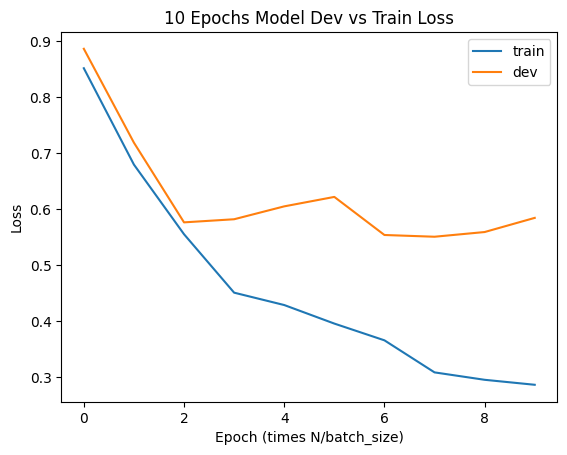

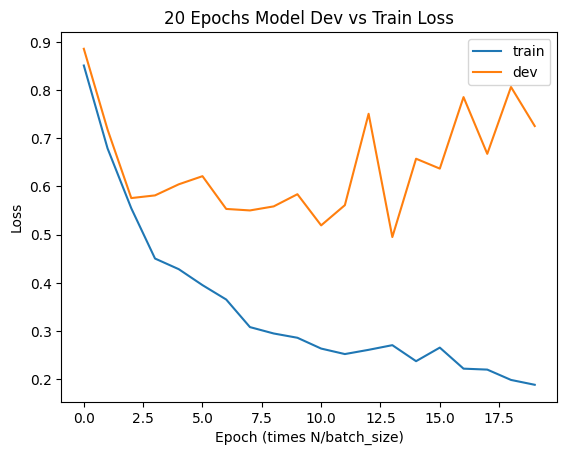

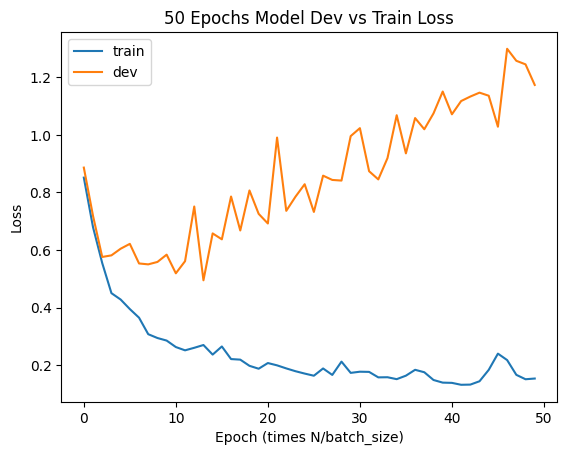

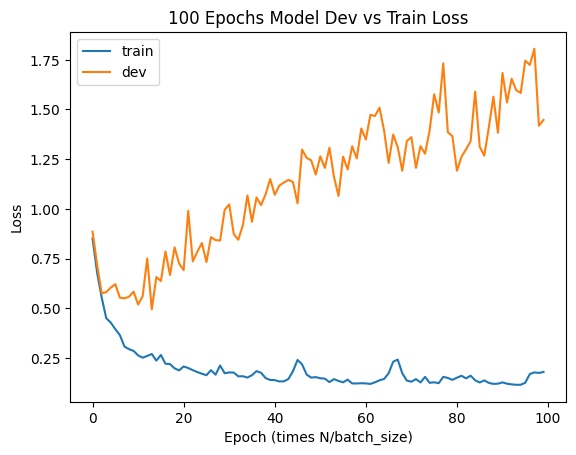

In [ ]:
for i, model in enumerate(models):
  plot_dev_train_loss(model[1], model[2], f"{epochs[i]} Epochs Model Dev vs Train Loss")

Plot accuracy:

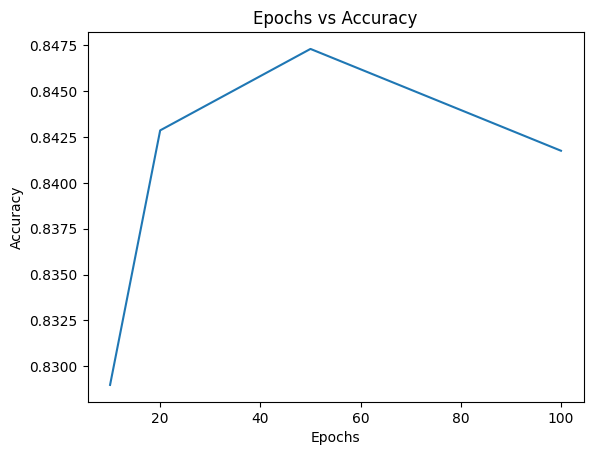

In [ ]:
plt.plot(epochs, accuracy_scores, label='accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Epochs vs Accuracy')
plt.show()

#Overfitting Control

We will intentionally induce overfitting with a larger neural network and too many epochs, and then fix it.

In [ ]:
large_model, optimizer, loss_fn = initialize_model(hl_size=100)
dev_loss, train_loss = train_model(large_model, optimizer, loss_fn, epochs=100, print_step=None)

Accuracy: 0.8712


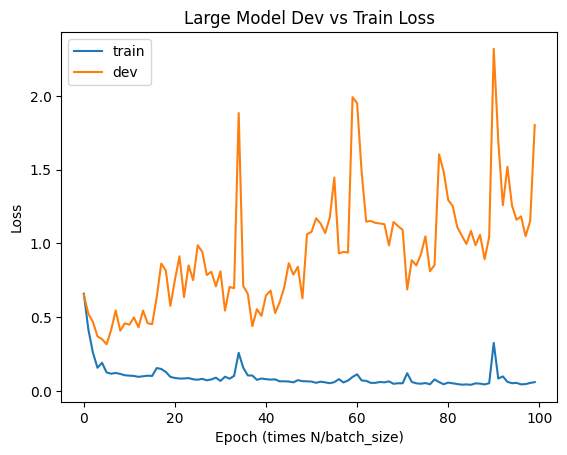

Final Dev Loss: 1.8016


In [ ]:
large_model.eval()
with torch.no_grad():
  y_pred = large_model(x_test_flat)
  accuracy = accuracy_score(y_test_encoded.argmax(dim=-1), y_pred.argmax(dim=-1))
  print(f"Accuracy: {accuracy:.4f}")
  plot_dev_train_loss(dev_loss, train_loss, "Large Model Dev vs Train Loss")
  print(f"Final Dev Loss: {dev_loss[-1]:.4f}")

As we can see, the final loss on the dev set is very high, showing that we are clearly overfitting on the data.

In [ ]:
class NeuralNetworkImproved(nn.Module):
    def __init__(self, hl_size=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(128*9, hl_size),
            nn.ReLU(),
            nn.Dropout(p=0.2),    # add dropout
            nn.Linear(hl_size, 10),
            nn.ReLU(),
            nn.Dropout(p=0.2),    # add dropout
            nn.Linear(10, 6)
        )

    def forward(self, x):
        logits = self.linear_relu_stack(x)
        return logits

# function to initialize model (so we can test different hyperparams)
def initialize_improved_model(lr=0.01, hl_size=10, weight_decay = 0.01):
  model = NeuralNetworkImproved(hl_size=hl_size)
  optimizer = torch.optim.AdamW(model.parameters(),lr=lr, weight_decay = weight_decay)
  loss_fn = nn.CrossEntropyLoss()
  return model, optimizer, loss_fn

In [ ]:
# create improved model with same large size
large_model, optimizer, loss_fn = initialize_improved_model(hl_size=100)
dev_loss, train_loss = train_model(large_model, optimizer, loss_fn, epochs=100, print_step=None)

Accuracy: 0.9373


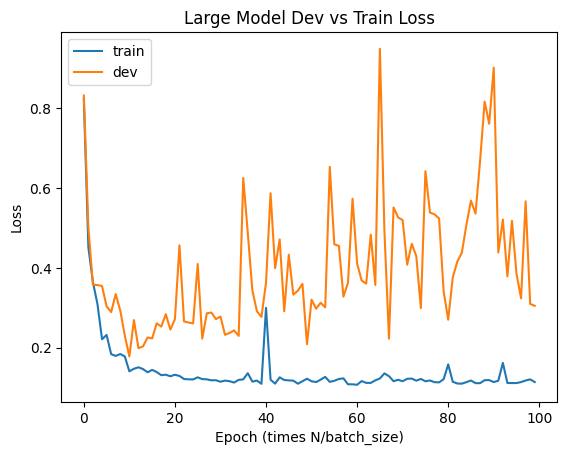

Final Dev Loss: 0.3044


In [ ]:
large_model.eval()
with torch.no_grad():
  y_pred = large_model(x_test_flat)
  accuracy = accuracy_score(y_test_encoded.argmax(dim=-1), y_pred.argmax(dim=-1))
  print(f"Accuracy: {accuracy:.4f}")
  plot_dev_train_loss(dev_loss, train_loss, "Large Model Dev vs Train Loss")
  print(f"Final Dev Loss: {dev_loss[-1]:.4f}")

The final loss is much better now, and so is the accuracy. While this loss still spikes, as we can see from the graph, the spiking is on a smaller scale than the original model without weight decay and dropout.

#Instability Debugging

In [ ]:
unstable_model, optimizer, loss_fn = initialize_improved_model(lr = 1e-5, hl_size=2, weight_decay = 3.0)
dev_loss, train_loss = train_model(unstable_model, optimizer, loss_fn, epochs=100, print_step=None)

Accuracy: 0.1838


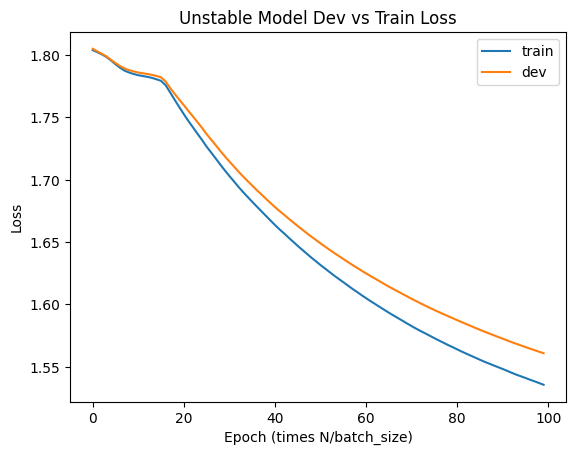

Final Dev Loss: 1.5609


In [ ]:
unstable_model.eval()
with torch.no_grad():
  y_pred = unstable_model(x_test_flat)
  accuracy = accuracy_score(y_test_encoded.argmax(dim=-1), y_pred.argmax(dim=-1))
  print(f"Accuracy: {accuracy:.4f}")
  plot_dev_train_loss(dev_loss, train_loss, "Unstable Model Dev vs Train Loss")
  print(f"Final Dev Loss: {dev_loss[-1]:.4f}")

This model is awful. Its performance is on par with the week 1 majority class preidctor on accuracy. We will begin by modifying the learning rate. The dev loss being higher than the training loss suggests the model is underfitted, which increasing the learning rate should help fix.

In [ ]:
stable_model, optimizer, loss_fn = initialize_improved_model(lr = 0.01, hl_size=10, weight_decay = 3.0)
dev_loss, train_loss = train_model(stable_model, optimizer, loss_fn, epochs=100, print_step=None)

Accuracy: 0.8096


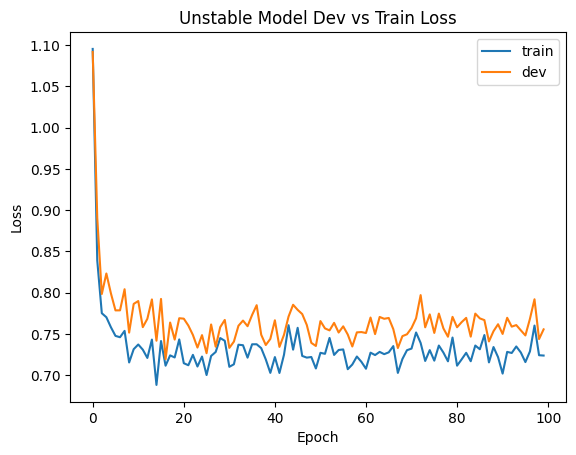

Final Dev Loss: 0.7554


In [ ]:
stable_model.eval()
with torch.no_grad():
  y_pred = stable_model(x_test_flat)
  accuracy = accuracy_score(y_test_encoded.argmax(dim=-1), y_pred.argmax(dim=-1))
  print(f"Accuracy: {accuracy:.4f}")
  plot_dev_train_loss(dev_loss, train_loss, "Unstable Model Dev vs Train Loss")
  print(f"Final Dev Loss: {dev_loss[-1]:.4f}")

The fluctuation in loss suggests the model has more freedom to descend the gradient. However, loss is still high and the dev loss is greater than the training loss, which suggests the model is still underfit. We will next modify weight decay to try to get the model to converge at a lower losss.

In [ ]:
stable_model, optimizer, loss_fn = initialize_improved_model(lr = 0.01, hl_size=10, weight_decay = 0.001)
dev_loss, train_loss = train_model(stable_model, optimizer, loss_fn, epochs=60, print_step=None)

Accuracy: 0.8773


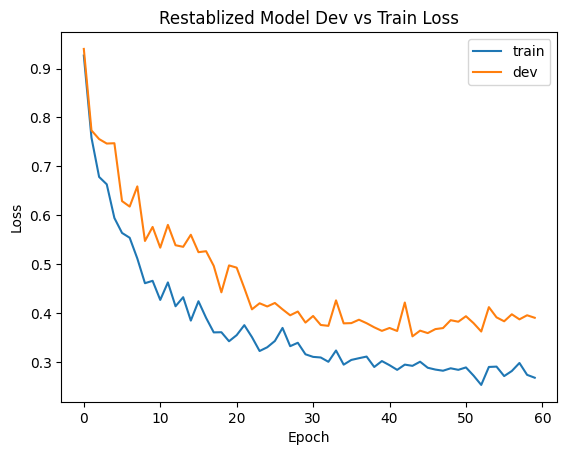

Final Dev Loss: 0.3902


In [ ]:
stable_model.eval()
with torch.no_grad():
  y_pred = stable_model(x_test_flat)
  accuracy = accuracy_score(y_test_encoded.argmax(dim=-1), y_pred.argmax(dim=-1))
  print(f"Accuracy: {accuracy:.4f}")
  plot_dev_train_loss(dev_loss, train_loss, "Restablized Model Dev vs Train Loss")
  print(f"Final Dev Loss: {dev_loss[-1]:.4f}")

After fixing learning rate and weight decay, our model now performs roughly on par with baseline again. We selected a number of epochs to be around when the dev loss stopped decreasing to avoid over or underfitting.

Experiment log entry

|test|
|test|